link:    https://www.kaggle.com/datasets/philipsanm/sentiment-analysis-in-spanish-tweets

In [1]:
!pip install seaborn scikit-learn matplotlib pandas numpy
!pip install pypandoc


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
# 1. IMPORTACIÓN DE LIBRERÍAS
# ====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Librerías para procesamiento de texto
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample
from collections import Counter
import unicodedata


In [4]:
# Para visualizaciones
plt.style.use('default')
sns.set_palette("husl")


In [5]:
# 2. CARGA Y EXPLORACIÓN INICIAL DE DATOS
# ====================================================================
print("🔄 Cargando dataset...")

# Cargar el dataset
df = pd.read_csv('sentiment_analysis_dataset.csv')

print("✅ Dataset cargado exitosamente!")
print(f"📊 Dimensiones del dataset: {df.shape}")
print("\n📋 Primeras 5 filas:")
print(df.head())

print("\n📈 Información del dataset:")
print(df.info())

print("\n📊 Valores nulos:")
print(df.isnull().sum())

print("\n🏷️ Distribución de sentimientos:")
print(df['sentiment'].value_counts())

print("\n🎭 Distribución de emociones:")
print(df['emotion'].value_counts())


🔄 Cargando dataset...
✅ Dataset cargado exitosamente!
📊 Dimensiones del dataset: (2590, 5)

📋 Primeras 5 filas:
             user                                               text  \
0      @erreborda               termine bien abrumado después de hoy   
1    @shpiderduck                                 me siento abrumado   
2     @Alex_R_art  Me siento un poco abrumado por la cantidad de ...   
3   @anggelinaa97  Salvador la única persona que no la ha abrumad...   
4  @diegoreyesvqz     Denme un helado o algo que ando full abrumado.   

                         date      emotion sentiment  
0   Jan 6, 2024 · 2:53 AM UTC  overwhelmed    scared  
1   Jan 6, 2024 · 2:35 AM UTC  overwhelmed    scared  
2  Jan 6, 2024 · 12:20 AM UTC  overwhelmed    scared  
3  Jan 5, 2024 · 10:38 PM UTC  overwhelmed    scared  
4   Jan 5, 2024 · 8:38 PM UTC  overwhelmed    scared  

📈 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2590 entries, 0 to 2589
Data columns (total 5 c


📈 ANÁLISIS ESTADÍSTICO EXPLORATORIO


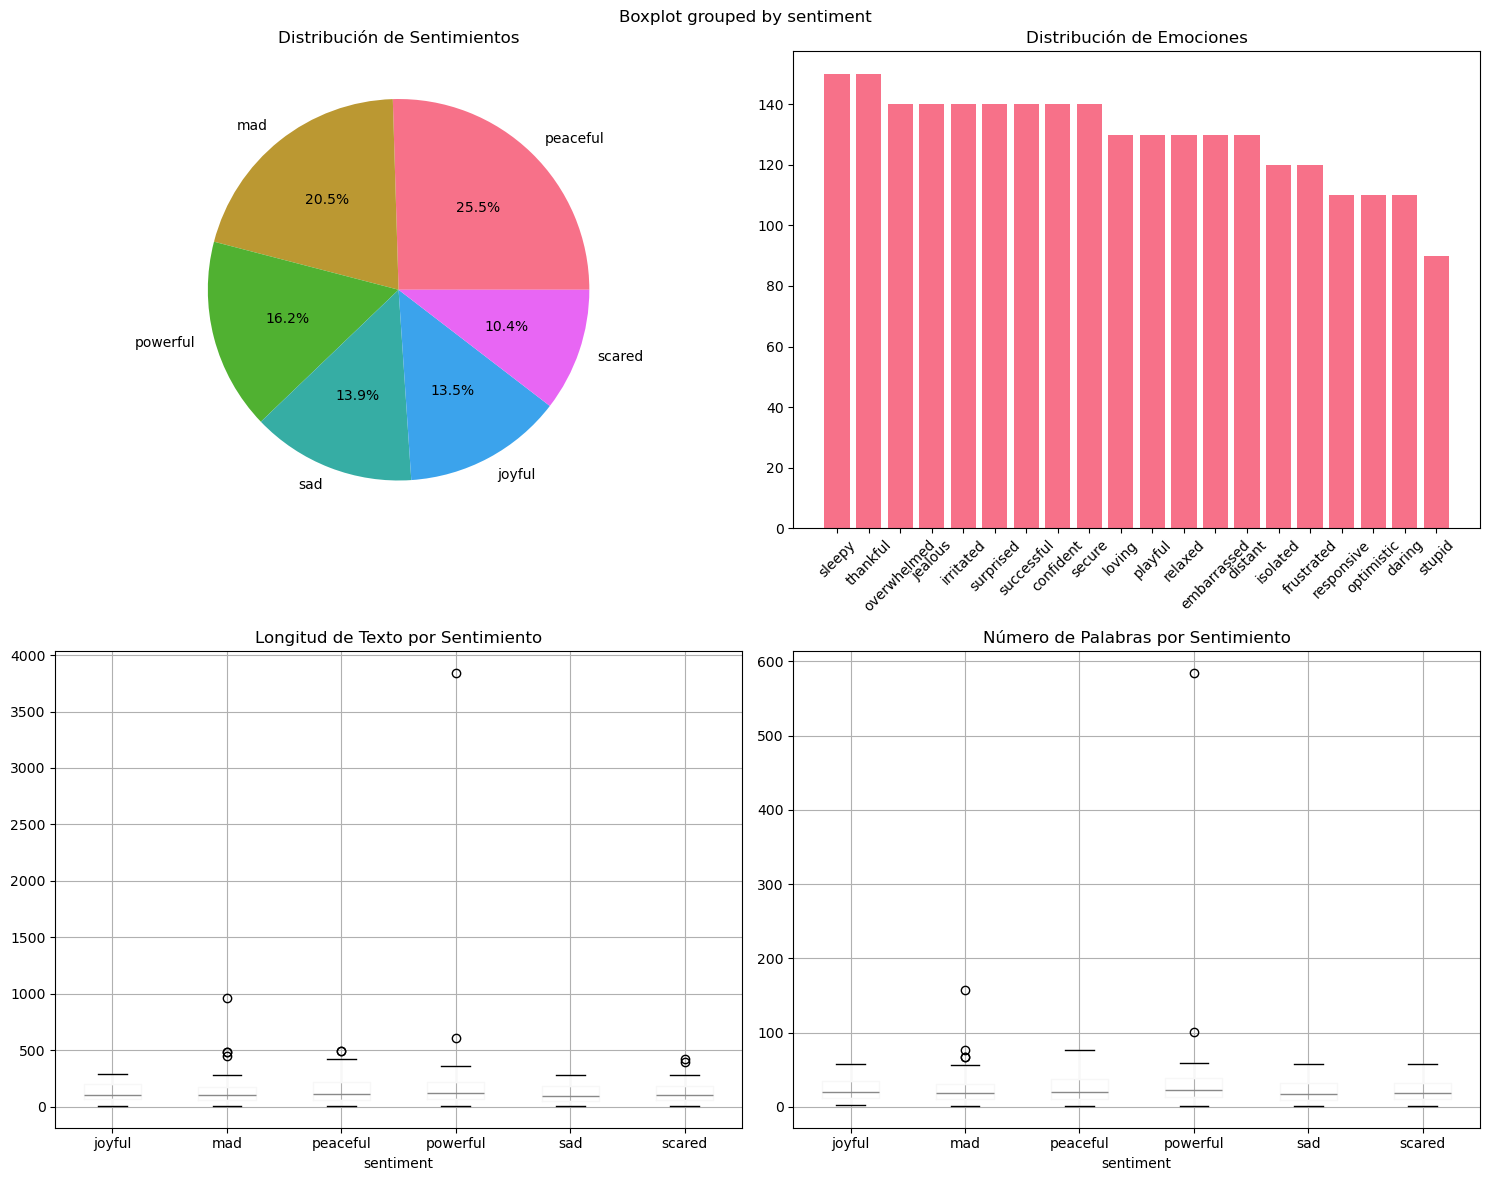


📊 Estadísticas de longitud de texto:
           count        mean         std  min    25%    50%     75%     max
sentiment                                                                  
joyful     350.0  132.520000   81.154163  7.0  67.00  105.5  198.00   289.0
mad        530.0  124.439623   90.222918  9.0  58.00   99.5  174.00   963.0
peaceful   660.0  135.574242   89.052229  6.0  58.00  110.0  217.25   493.0
powerful   420.0  153.473810  200.860694  9.0  72.00  121.0  221.00  3845.0
sad        360.0  123.847222   82.797309  7.0  53.75   98.0  185.25   280.0
scared     270.0  124.944444   86.071168  9.0  56.00   99.5  184.00   425.0

📊 Estadísticas de número de palabras:
           count       mean        std  min   25%   50%    75%    max
sentiment                                                            
joyful     350.0  23.494286  14.050206  2.0  12.0  20.0  35.00   57.0
mad        530.0  22.233962  15.686375  1.0  11.0  18.0  31.00  157.0
peaceful   660.0  24.024242  15.259

In [6]:
# 3. ANÁLISIS ESTADÍSTICO EXPLORATORIO
# ====================================================================
print("\n" + "="*60)
print("📈 ANÁLISIS ESTADÍSTICO EXPLORATORIO")
print("="*60)

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Distribución de sentimientos
sentiment_counts = df['sentiment'].value_counts()
axes[0,0].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%')
axes[0,0].set_title('Distribución de Sentimientos')

# Gráfico 2: Distribución de emociones
emotion_counts = df['emotion'].value_counts()
axes[0,1].bar(emotion_counts.index, emotion_counts.values)
axes[0,1].set_title('Distribución de Emociones')
axes[0,1].tick_params(axis='x', rotation=45)

# Gráfico 3: Longitud de texto por sentimiento
df['text_length'] = df['text'].str.len()
df.boxplot(column='text_length', by='sentiment', ax=axes[1,0])
axes[1,0].set_title('Longitud de Texto por Sentimiento')

# Gráfico 4: Número de palabras por sentimiento
df['word_count'] = df['text'].str.split().str.len()
df.boxplot(column='word_count', by='sentiment', ax=axes[1,1])
axes[1,1].set_title('Número de Palabras por Sentimiento')

plt.tight_layout()
plt.show()

# Estadísticas descriptivas
print("\n📊 Estadísticas de longitud de texto:")
print(df.groupby('sentiment')['text_length'].describe())

print("\n📊 Estadísticas de número de palabras:")
print(df.groupby('sentiment')['word_count'].describe())

In [7]:
# 4. LIMPIEZA Y PREPROCESAMIENTO DE TEXTO
# ====================================================================
print("\n" + "="*60)
print("🧹 LIMPIEZA Y PREPROCESAMIENTO DE TEXTO")
print("="*60)

def clean_text(text):
    """
    Función para limpiar y preprocesar texto en español
    """
    if pd.isna(text):
        return ""

    # Convertir a string
    text = str(text)

    # Convertir a minúsculas
    text = text.lower()

    # Remover caracteres especiales y números
    text = re.sub(r'[^a-záéíóúñü\s]', '', text)

    # Remover espacios extra
    text = re.sub(r'\s+', ' ', text)

    # Remover espacios al inicio y final
    text = text.strip()

    # Normalizar caracteres unicode (ej: Ã© -> é)
    text = unicodedata.normalize('NFD', text)
    text = ''.join(char for char in text if unicodedata.category(char) != 'Mn')

    return text

def remove_stopwords(text):
    """
    Remover palabras vacías en español
    """
    # Lista básica de stopwords en español
    spanish_stopwords = [
        'a', 'al', 'algo', 'algunas', 'algunos', 'ante', 'antes', 'como', 'con',
        'contra', 'cual', 'cuando', 'de', 'del', 'desde', 'donde', 'durante',
        'e', 'el', 'ella', 'ellas', 'ellos', 'en', 'entre', 'era', 'erais',
        'eran', 'eras', 'eres', 'es', 'esa', 'esas', 'ese', 'eso', 'esos',
        'esta', 'estaba', 'estabais', 'estaban', 'estabas', 'estad', 'estada',
        'estadas', 'estado', 'estados', 'estamos', 'estando', 'estar', 'estara',
        'estaran', 'estaras', 'estare', 'estareis', 'estaremos', 'estaria',
        'estarian', 'estarias', 'estaríamos', 'estaríais', 'estas', 'este',
        'estemos', 'esto', 'estos', 'estoy', 'estuve', 'estuviera', 'estuvierais',
        'estuvieran', 'estuvieras', 'estuvieron', 'estuviese', 'estuvieseis',
        'estuviesen', 'estuvieses', 'estuvimos', 'estuviste', 'estuvisteis',
        'estuvo', 'fue', 'fuera', 'fuerais', 'fueran', 'fueras', 'fueron',
        'fuese', 'fueseis', 'fuesen', 'fueses', 'fui', 'fuimos', 'fuiste',
        'fuisteis', 'ha', 'habeis', 'habia', 'habiais', 'habian', 'habias',
        'habida', 'habidas', 'habido', 'habidos', 'habiendo', 'habra', 'habran',
        'habras', 'habre', 'habreis', 'habremos', 'habria', 'habrian', 'habrias',
        'habriamos', 'habriais', 'han', 'has', 'hasta', 'hay', 'haya', 'hayais',
        'hayan', 'hayas', 'hayamos', 'he', 'hemos', 'hube', 'hubiera', 'hubierais',
        'hubieran', 'hubieras', 'hubieron', 'hubiese', 'hubieseis', 'hubiesen',
        'hubieses', 'hubimos', 'hubiste', 'hubisteis', 'hubo', 'la', 'las', 'le',
        'les', 'lo', 'los', 'me', 'mi', 'mis', 'mucho', 'muchos', 'muy', 'mas',
        'ni', 'no', 'nos', 'nosotras', 'nosotros', 'nuestra', 'nuestras',
        'nuestro', 'nuestros', 'o', 'os', 'otra', 'otras', 'otro', 'otros',
        'para', 'pero', 'por', 'porque', 'que', 'quien', 'quienes', 'se', 'sea',
        'seais', 'seamos', 'sean', 'seas', 'sera', 'seran', 'seras', 'sere',
        'sereis', 'seremos', 'seria', 'serian', 'serias', 'seriamos', 'seriais',
        'si', 'siendo', 'sin', 'sobre', 'sois', 'somos', 'son', 'soy', 'su',
        'sus', 'suya', 'suyas', 'suyo', 'suyos', 'tambien', 'tanto', 'te',
        'tendremos', 'tendra', 'tendran', 'tendras', 'tendre', 'tendreis',
        'tendria', 'tendrian', 'tendrias', 'tendriamos', 'tendriais', 'tenemos',
        'tener', 'tenga', 'tengais', 'tengamos', 'tengan', 'tengas', 'tengo',
        'tenia', 'teniais', 'tenian', 'tenias', 'tenida', 'tenidas', 'tenido',
        'tenidos', 'teniendo', 'ti', 'tiene', 'tienen', 'tienes', 'todo',
        'todos', 'tu', 'tus', 'tuvo', 'tuviera', 'tuvierais', 'tuvieran',
        'tuvieras', 'tuvieron', 'tuviese', 'tuvieseis', 'tuviesen', 'tuvieses',
        'tuvimos', 'tuviste', 'tuvisteis', 'tuya', 'tuyas', 'tuyo', 'tuyos',
        'un', 'una', 'uno', 'unos', 'va', 'vais', 'vamos', 'van', 'vas', 've',
        'vosotras', 'vosotros', 'vuestra', 'vuestras', 'vuestro', 'vuestros',
        'y', 'ya', 'yo', 'rt', 'via'
    ]

    words = text.split()
    words = [word for word in words if word not in spanish_stopwords and len(word) > 2]
    return ' '.join(words)

# Aplicar limpieza
print("🧹 Limpiando textos...")
df['text_clean'] = df['text'].apply(clean_text)
df['text_clean'] = df['text_clean'].apply(remove_stopwords)

# Remover filas con texto vacío después de la limpieza
df = df[df['text_clean'].str.len() > 0].reset_index(drop=True)

print(f"✅ Limpieza completada. Registros restantes: {len(df)}")
print("\n📝 Ejemplo de limpieza:")
sample_idx = 0
print(f"Texto original: {df.iloc[sample_idx]['text']}")
print(f"Texto limpio: {df.iloc[sample_idx]['text_clean']}")




🧹 LIMPIEZA Y PREPROCESAMIENTO DE TEXTO
🧹 Limpiando textos...
✅ Limpieza completada. Registros restantes: 2590

📝 Ejemplo de limpieza:
Texto original: termine bien abrumado después de hoy
Texto limpio: termine bien abrumado despues hoy



⚖️ ANÁLISIS DE BALANCEO DE CLASES
📊 Distribución actual de sentimientos:
  peaceful: 660 (25.5%)
  mad: 530 (20.5%)
  powerful: 420 (16.2%)
  sad: 360 (13.9%)
  joyful: 350 (13.5%)
  scared: 270 (10.4%)


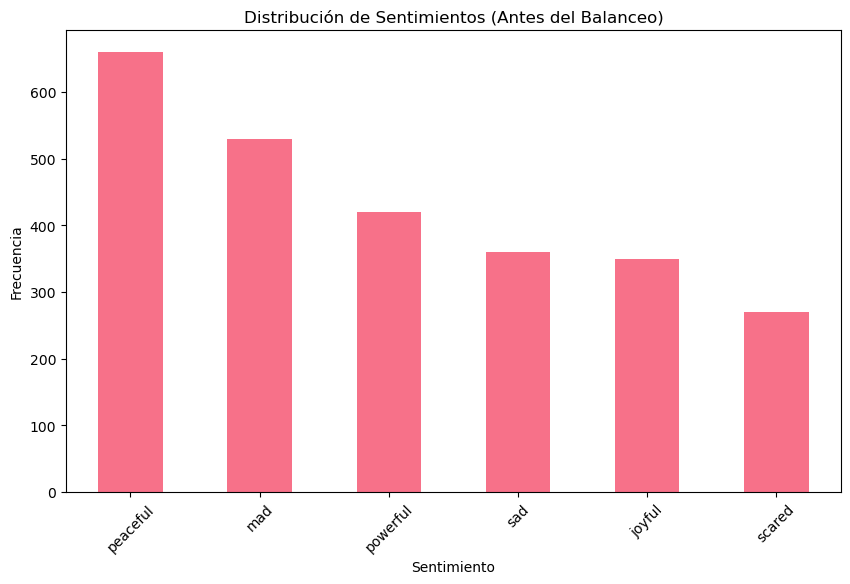


🔄 Aplicando balanceo de clases...
Tamaño de la clase minoritaria: 270
✅ Balanceo completado. Nuevo tamaño del dataset: 1620

📊 Distribución después del balanceo:
  scared: 270 (16.7%)
  mad: 270 (16.7%)
  joyful: 270 (16.7%)
  sad: 270 (16.7%)
  powerful: 270 (16.7%)
  peaceful: 270 (16.7%)


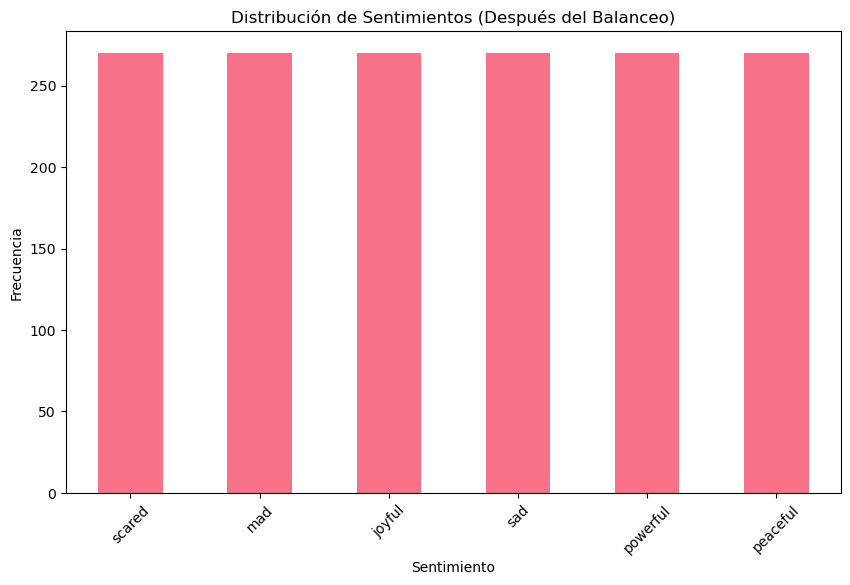

In [8]:
# 5. ANÁLISIS DE BALANCEO DE CLASES
# ====================================================================
print("\n" + "="*60)
print("⚖️ ANÁLISIS DE BALANCEO DE CLASES")
print("="*60)

# Mostrar distribución actual
sentiment_dist = df['sentiment'].value_counts()
print("📊 Distribución actual de sentimientos:")
for sentiment, count in sentiment_dist.items():
    percentage = (count / len(df)) * 100
    print(f"  {sentiment}: {count} ({percentage:.1f}%)")

# Visualizar desbalance
plt.figure(figsize=(10, 6))
sentiment_dist.plot(kind='bar')
plt.title('Distribución de Sentimientos (Antes del Balanceo)')
plt.xlabel('Sentimiento')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

# BALANCEO DE CLASES usando Undersampling
print("\n🔄 Aplicando balanceo de clases...")

# Encontrar la clase minoritaria
min_class_size = sentiment_dist.min()
print(f"Tamaño de la clase minoritaria: {min_class_size}")

# Balancear las clases
df_balanced = pd.DataFrame()

for sentiment in df['sentiment'].unique():
    # Obtener todas las muestras de esta clase
    df_class = df[df['sentiment'] == sentiment]

    # Hacer undersample a min_class_size
    df_class_sampled = resample(df_class,
                               replace=False,
                               n_samples=min_class_size,
                               random_state=42)

    # Añadir al dataframe balanceado
    df_balanced = pd.concat([df_balanced, df_class_sampled])

# Mezclar el dataframe
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ Balanceo completado. Nuevo tamaño del dataset: {len(df_balanced)}")

# Mostrar nueva distribución
balanced_dist = df_balanced['sentiment'].value_counts()
print("\n📊 Distribución después del balanceo:")
for sentiment, count in balanced_dist.items():
    percentage = (count / len(df_balanced)) * 100
    print(f"  {sentiment}: {count} ({percentage:.1f}%)")

# Visualizar después del balanceo
plt.figure(figsize=(10, 6))
balanced_dist.plot(kind='bar')
plt.title('Distribución de Sentimientos (Después del Balanceo)')
plt.xlabel('Sentimiento')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()


In [9]:
# 6. PREPARACIÓN DE DATOS PARA MODELO
# ====================================================================
print("\n" + "="*60)
print("🎯 PREPARACIÓN DE DATOS PARA EL MODELO")
print("="*60)

# Usar el dataset balanceado
X = df_balanced['text_clean']
y = df_balanced['sentiment']

print(f"📊 Características (X): {len(X)} textos")
print(f"🎯 Etiquetas (y): {len(y)} sentimientos")

# División en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ División completada:")
print(f"  Entrenamiento: {len(X_train)} muestras")
print(f"  Prueba: {len(X_test)} muestras")

# Verificar distribución en conjuntos
print(f"\n📊 Distribución en entrenamiento:")
print(y_train.value_counts())
print(f"\n📊 Distribución en prueba:")
print(y_test.value_counts())


🎯 PREPARACIÓN DE DATOS PARA EL MODELO
📊 Características (X): 1620 textos
🎯 Etiquetas (y): 1620 sentimientos

✅ División completada:
  Entrenamiento: 1296 muestras
  Prueba: 324 muestras

📊 Distribución en entrenamiento:
sentiment
sad         216
joyful      216
scared      216
mad         216
peaceful    216
powerful    216
Name: count, dtype: int64

📊 Distribución en prueba:
sentiment
peaceful    54
scared      54
joyful      54
mad         54
powerful    54
sad         54
Name: count, dtype: int64


In [10]:
# 7. VECTORIZACIÓN DE TEXTO
# ====================================================================
print("\n" + "="*60)
print("🔤 VECTORIZACIÓN DE TEXTO")
print("="*60)

# Crear el vectorizador
vectorizer = CountVectorizer(
    max_features=5000,  # Máximo 5000 características
    ngram_range=(1, 2), # Usar unigramas y bigramas
    min_df=2,          # Palabra debe aparecer al menos 2 veces
    max_df=0.8         # Palabra no debe aparecer en más del 80% de documentos
)

# Entrenar el vectorizador y transformar datos
print("🔄 Vectorizando textos...")
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"✅ Vectorización completada:")
print(f"  Vocabulario: {len(vectorizer.vocabulary_)} palabras/frases")
print(f"  Matriz de entrenamiento: {X_train_vec.shape}")
print(f"  Matriz de prueba: {X_test_vec.shape}")

# Mostrar las palabras más comunes
feature_names = vectorizer.get_feature_names_out()
word_freq = np.array(X_train_vec.sum(axis=0)).flatten()
top_words = [(feature_names[i], word_freq[i]) for i in word_freq.argsort()[-20:][::-1]]

print(f"\n🔝 Top 20 palabras/frases más frecuentes:")
for word, freq in top_words:
    print(f"  {word}: {freq}")



🔤 VECTORIZACIÓN DE TEXTO
🔄 Vectorizando textos...
✅ Vectorización completada:
  Vocabulario: 3226 palabras/frases
  Matriz de entrenamiento: (1296, 3226)
  Matriz de prueba: (324, 3226)

🔝 Top 20 palabras/frases más frecuentes:
  ser: 108
  tan: 86
  vida: 75
  solo: 75
  gente: 59
  hoy: 57
  bien: 53
  hacer: 52
  nada: 51
  ver: 46
  ahora: 46
  dia: 45
  vez: 44
  ano: 42
  poco: 40
  siento: 40
  mejor: 40
  asi: 39
  nunca: 39
  hace: 37


In [11]:
# 8. ENTRENAMIENTO DEL MODELO NAIVE BAYES
# ====================================================================
print("\n" + "="*60)
print("🤖 ENTRENAMIENTO DEL MODELO NAIVE BAYES")
print("="*60)

# Crear el modelo Multinomial Naive Bayes
model = MultinomialNB(alpha=1.0)  # alpha=1.0 es suavizado de Laplace

print("🔄 Entrenando modelo...")
model.fit(X_train_vec, y_train)
print("✅ Modelo entrenado exitosamente!")


🤖 ENTRENAMIENTO DEL MODELO NAIVE BAYES
🔄 Entrenando modelo...
✅ Modelo entrenado exitosamente!



📊 EVALUACIÓN DEL MODELO
🎯 Exactitud (Accuracy): 0.5741 (57.41%)
📊 Validación cruzada (5-fold): 0.5772 ± 0.0348

📋 Reporte de clasificación:
              precision    recall  f1-score   support

      joyful       0.58      0.59      0.59        54
         mad       0.60      0.59      0.60        54
    peaceful       0.44      0.46      0.45        54
    powerful       0.51      0.54      0.52        54
         sad       0.60      0.57      0.58        54
      scared       0.74      0.69      0.71        54

    accuracy                           0.57       324
   macro avg       0.58      0.57      0.58       324
weighted avg       0.58      0.57      0.58       324



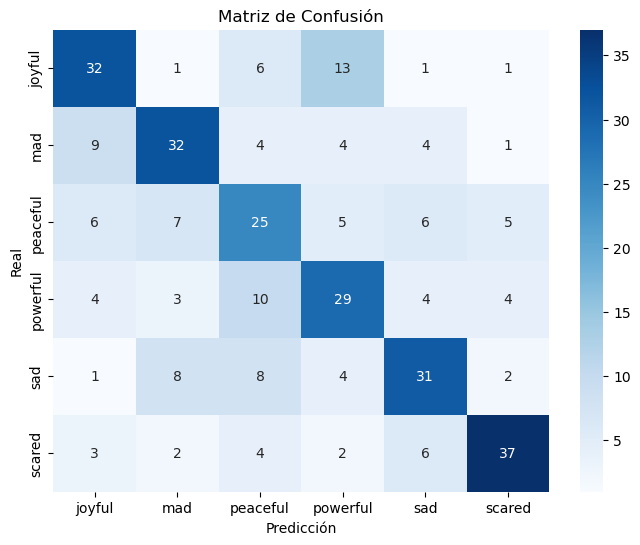

In [12]:
# 9. EVALUACIÓN DEL MODELO
# ====================================================================
print("\n" + "="*60)
print("📊 EVALUACIÓN DEL MODELO")
print("="*60)

# Predicciones
y_pred = model.predict(X_test_vec)
y_pred_proba = model.predict_proba(X_test_vec)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Exactitud (Accuracy): {accuracy:.4f} ({accuracy*100:.2f}%)")

# Validación cruzada
cv_scores = cross_val_score(model, X_train_vec, y_train, cv=5, scoring='accuracy')
print(f"📊 Validación cruzada (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Reporte de clasificación
print(f"\n📋 Reporte de clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()



🔍 INTERPRETACIÓN DEL MODELO
🏷️ Palabras más importantes por sentimiento:
--------------------------------------------------

📌 JOYFUL:
  tan: -5.6348
  ser: -5.8066
  animado: -5.8712
  sino: -5.8712
  hacer: -5.8712
  solo: -6.0143
  dia: -6.0143
  vida: -6.0143
  puede: -6.0943
  ver: -6.0943
  pensar: -6.1813
  cosas: -6.2766
  osadia: -6.2766
  cada: -6.2766
  distinto: -6.2766

📌 MAD:
  gente: -5.5615
  tan: -5.5615
  solo: -5.6668
  ser: -5.7240
  vida: -6.0723
  molesto: -6.0723
  ahora: -6.1593
  bien: -6.2546
  furioso: -6.3600
  ver: -6.3600
  hoy: -6.3600
  asi: -6.3600
  contrariado: -6.3600
  rapido: -6.4777
  mejor: -6.4777

📌 PEACEFUL:
  rapido: -5.6705
  tan: -5.7276
  vida: -5.7882
  bien: -5.7882
  ser: -5.8528
  solo: -5.8528
  personas: -6.0759
  hoy: -6.0759
  nada: -6.2582
  amor: -6.2582
  amo: -6.2582
  atento: -6.2582
  ano: -6.2582
  quiero: -6.3636
  gracias: -6.3636

📌 POWERFUL:
  ser: -5.1283
  vida: -5.4893
  gente: -5.9167
  alguien: -5.9167
  vez: -5.98

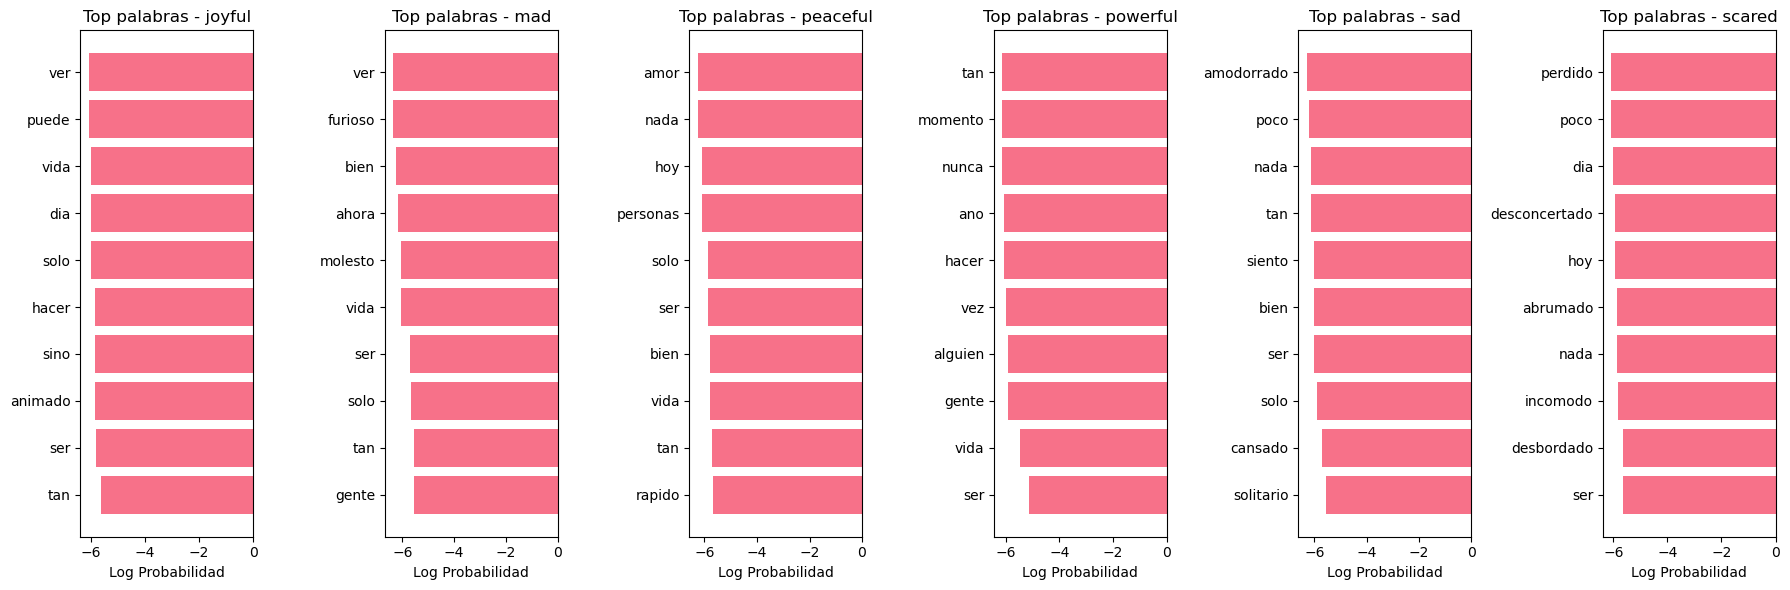

In [13]:
# 10. INTERPRETACIÓN DEL MODELO
# ====================================================================
print("\n" + "="*60)
print("🔍 INTERPRETACIÓN DEL MODELO")
print("="*60)

# Obtener las palabras más importantes para cada clase
feature_names = vectorizer.get_feature_names_out()
n_top_words = 15

print("🏷️ Palabras más importantes por sentimiento:")
print("-" * 50)

for i, class_name in enumerate(model.classes_):
    # Obtener los coeficientes (log probabilidades) para esta clase
    top_indices = model.feature_log_prob_[i].argsort()[-n_top_words:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    top_probs = [model.feature_log_prob_[i][idx] for idx in top_indices]

    print(f"\n📌 {class_name.upper()}:")
    for word, prob in zip(top_words, top_probs):
        print(f"  {word}: {prob:.4f}")

# Visualización de palabras importantes
fig, axes = plt.subplots(1, len(model.classes_), figsize=(18, 6))
if len(model.classes_) == 1:
    axes = [axes]

for i, class_name in enumerate(model.classes_):
    top_indices = model.feature_log_prob_[i].argsort()[-10:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    top_probs = [model.feature_log_prob_[i][idx] for idx in top_indices]

    axes[i].barh(range(len(top_words)), top_probs)
    axes[i].set_yticks(range(len(top_words)))
    axes[i].set_yticklabels(top_words)
    axes[i].set_title(f'Top palabras - {class_name}')
    axes[i].set_xlabel('Log Probabilidad')

plt.tight_layout()
plt.show()


In [14]:
# 11. CASOS DE USO Y PREDICCIONES
# ====================================================================
print("\n" + "="*60)
print("🔮 CASOS DE USO Y PREDICCIONES")
print("="*60)

def predict_sentiment(text, model, vectorizer):
    """
    Predice el sentimiento de un texto dado
    """
    # Limpiar el texto
    cleaned_text = clean_text(text)
    cleaned_text = remove_stopwords(cleaned_text)

    # Vectorizar
    text_vec = vectorizer.transform([cleaned_text])

    # Predecir
    prediction = model.predict(text_vec)[0]
    probabilities = model.predict_proba(text_vec)[0]

    # Crear diccionario de probabilidades
    prob_dict = dict(zip(model.classes_, probabilities))

    return prediction, prob_dict, cleaned_text

# Casos de prueba
test_cases = [
    "Me siento muy feliz y contento con mi vida",
    "Estoy triste y deprimido, todo va mal",
    "¡Qué película tan increíble! Me encantó",
    "Esta comida está horrible, no la recomiendo",
    "El clima está perfecto para salir",
    "Tengo miedo de lo que pueda pasar",
    "Me sorprendió mucho esa noticia",
    "Estoy muy enojado con esta situación"
]

print("🎯 Predicciones en casos de ejemplo:")
print("-" * 80)

for i, text in enumerate(test_cases, 1):
    prediction, probabilities, cleaned = predict_sentiment(text, model, vectorizer)

    print(f"\n{i}. Texto: '{text}'")
    print(f"   Texto limpio: '{cleaned}'")
    print(f"   Predicción: {prediction}")
    print(f"   Probabilidades:")
    for sentiment, prob in probabilities.items():
        print(f"     {sentiment}: {prob:.4f} ({prob*100:.1f}%)")


🔮 CASOS DE USO Y PREDICCIONES
🎯 Predicciones en casos de ejemplo:
--------------------------------------------------------------------------------

1. Texto: 'Me siento muy feliz y contento con mi vida'
   Texto limpio: 'siento feliz contento vida'
   Predicción: mad
   Probabilidades:
     joyful: 0.1644 (16.4%)
     mad: 0.2368 (23.7%)
     peaceful: 0.2334 (23.3%)
     powerful: 0.1732 (17.3%)
     sad: 0.0759 (7.6%)
     scared: 0.1163 (11.6%)

2. Texto: 'Estoy triste y deprimido, todo va mal'
   Texto limpio: 'triste deprimido mal'
   Predicción: scared
   Probabilidades:
     joyful: 0.1344 (13.4%)
     mad: 0.1026 (10.3%)
     peaceful: 0.0406 (4.1%)
     powerful: 0.0670 (6.7%)
     sad: 0.0603 (6.0%)
     scared: 0.5952 (59.5%)

3. Texto: '¡Qué película tan increíble! Me encantó'
   Texto limpio: 'pelicula tan increible encanto'
   Predicción: peaceful
   Probabilidades:
     joyful: 0.0923 (9.2%)
     mad: 0.1557 (15.6%)
     peaceful: 0.2618 (26.2%)
     powerful: 0.2288 (2

In [15]:
# 12. FUNCIÓN INTERACTIVA PARA NUEVAS PREDICCIONES
# ====================================================================
print("\n" + "="*60)
print("💡 FUNCIÓN PARA USAR EL MODELO")
print("="*60)

def analizar_sentimiento_usuario(texto_usuario):
    """
    Función principal para analizar el sentimiento de cualquier texto
    """
    print(f"\n🔍 Analizando: '{texto_usuario}'")

    prediction, probabilities, cleaned = predict_sentiment(texto_usuario, model, vectorizer)

    print(f"📝 Texto procesado: '{cleaned}'")
    print(f"🎯 Sentimiento predicho: {prediction}")
    print(f"📊 Confianza del modelo:")

    # Ordenar probabilidades de mayor a menor
    sorted_probs = sorted(probabilities.items(), key=lambda x: x[1], reverse=True)

    for sentiment, prob in sorted_probs:
        bar = "█" * int(prob * 20)  # Barra visual de confianza
        print(f"   {sentiment}: {prob:.4f} ({prob*100:.1f}%) {bar}")

    return prediction, probabilities

# Ejemplo de uso
print("\n📋 Ejemplo de uso de la función:")
ejemplo_texto = "Estoy muy emocionado por las vacaciones"
resultado = analizar_sentimiento_usuario(ejemplo_texto)


💡 FUNCIÓN PARA USAR EL MODELO

📋 Ejemplo de uso de la función:

🔍 Analizando: 'Estoy muy emocionado por las vacaciones'
📝 Texto procesado: 'emocionado vacaciones'
🎯 Sentimiento predicho: scared
📊 Confianza del modelo:
   scared: 0.3221 (32.2%) ██████
   joyful: 0.1713 (17.1%) ███
   sad: 0.1680 (16.8%) ███
   powerful: 0.1637 (16.4%) ███
   mad: 0.0876 (8.8%) █
   peaceful: 0.0873 (8.7%) █


In [16]:
# 13. GUARDADO DEL MODELO (OPCIONAL)
# ====================================================================
print("\n" + "="*60)
print("💾 INFORMACIÓN PARA GUARDAR EL MODELO")
print("="*60)

print("Para guardar el modelo entrenado, puedes usar:")
print("```python")
print("import joblib")
print("joblib.dump(model, 'modelo_sentimientos.pkl')")
print("joblib.dump(vectorizer, 'vectorizer_sentimientos.pkl')")
print("```")

print("\nPara cargar el modelo:")
print("```python")
print("model = joblib.load('modelo_sentimientos.pkl')")
print("vectorizer = joblib.load('vectorizer_sentimientos.pkl')")
print("```")



💾 INFORMACIÓN PARA GUARDAR EL MODELO
Para guardar el modelo entrenado, puedes usar:
```python
import joblib
joblib.dump(model, 'modelo_sentimientos.pkl')
joblib.dump(vectorizer, 'vectorizer_sentimientos.pkl')
```

Para cargar el modelo:
```python
model = joblib.load('modelo_sentimientos.pkl')
vectorizer = joblib.load('vectorizer_sentimientos.pkl')
```


In [17]:
# 14. RESUMEN FINAL Y CONCLUSIONES
# ====================================================================
print("\n" + "="*60)
print("🎉 RESUMEN FINAL DEL ANÁLISIS")
print("="*60)

print(f"""
✅ ANÁLISIS COMPLETADO EXITOSAMENTE

📊 Estadísticas del dataset:
   • Dataset original: {df.shape[0]} muestras
   • Dataset balanceado: {len(df_balanced)} muestras
   • Conjunto de entrenamiento: {len(X_train)} muestras
   • Conjunto de prueba: {len(X_test)} muestras

🎯 Rendimiento del modelo:
   • Exactitud: {accuracy:.4f} ({accuracy*100:.2f}%)
   • Validación cruzada: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}

🔧 Características técnicas:
   • Algoritmo: Multinomial Naive Bayes
   • Vocabulario: {len(vectorizer.vocabulary_)} términos
   • N-gramas: unigramas y bigramas
   • Balanceo: Undersampling

💡 El modelo está listo para predecir sentimientos en tweets en español.
   Usa la función 'analizar_sentimiento_usuario()' para nuevas predicciones.
""")


🎉 RESUMEN FINAL DEL ANÁLISIS

✅ ANÁLISIS COMPLETADO EXITOSAMENTE

📊 Estadísticas del dataset:
   • Dataset original: 2590 muestras
   • Dataset balanceado: 1620 muestras
   • Conjunto de entrenamiento: 1296 muestras
   • Conjunto de prueba: 324 muestras

🎯 Rendimiento del modelo:
   • Exactitud: 0.5741 (57.41%)
   • Validación cruzada: 0.5772 ± 0.0348

🔧 Características técnicas:
   • Algoritmo: Multinomial Naive Bayes
   • Vocabulario: 3226 términos
   • N-gramas: unigramas y bigramas
   • Balanceo: Undersampling

💡 El modelo está listo para predecir sentimientos en tweets en español.
   Usa la función 'analizar_sentimiento_usuario()' para nuevas predicciones.



Defaulting to user installation because normal site-packages is not writeable
